In [1]:
import pandas as pd
import os, gc, re
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 경고 뜨지 않게 설정
import warnings
warnings.filterwarnings('ignore')

# 그래프 설정
sns.set()

# 그래프 기본 설정
plt.rcParams['font.family'] = 'NanumGothic'
# plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['figure.figsize'] = 12, 6
plt.rcParams['font.size'] = 14
plt.rcParams['axes.unicode_minus'] = False


In [2]:
def mean_barplot(df, cols, cols_n, seg):
    means = df[cols].mean().sort_values()
    print(means)
    plt.figure(figsize=(10, 5))
    sns.barplot(x=means.index, y=means.values)
    plt.title(f"{cols_n} 컬럼별 평균값 비교")
    plt.ylabel("평균")
    plt.xlabel(f"{seg}")
    plt.xticks()
    plt.tight_layout()
    plt.show()


# mean_barplot(A, 카드수, '카드수', 'A')
# mean_barplot(B, 카드수, '카드수', 'B')
# mean_barplot(C, 카드수, '카드수', 'C')
# mean_barplot(D, 카드수, '카드수', 'D')
# mean_barplot(E, 카드수, '카드수', 'E')

In [3]:
def median_barplot(df, cols, cols_n, seg):
    means = df[cols].median().sort_values()

    plt.figure(figsize=(10, 5))
    sns.barplot(x=means.index, y=means.values)
    plt.title(f"{cols_n} 컬럼별 중앙값 비교")
    plt.ylabel("중앙값")
    plt.xlabel(f"{seg}")
    plt.xticks()
    plt.tight_layout()
    plt.show()

In [4]:

def grouped_plot(col_list, plot_title):
    tot_cols = ['Segment'] + col_list
    # print(tot_cols)
    # 데이터 준비
    grouped_df = df[tot_cols] \
                    .groupby('Segment').mean().round()
    
    display(grouped_df)
    # 스타일 설정
    # plt.figure(figsize=(10, 6))
    ax = grouped_df.plot(kind='bar', figsize=(10, 6))  # 새 Figure 생성되므로 plt.figure 생략 가능

    ax.set_title(f'Segment별 {plot_title} 평균')
    ax.set_xlabel('Segment')
    ax.set_xticklabels(grouped_df.index, rotation=0)
    ax.set_ylabel('평균 값')
    ax.legend(title='이용 유형')
    
    plt.tight_layout()
    plt.show()

In [5]:
path = 'C:/final_prj/EDA/'
print(os.listdir(path))

['hyper_pred_ver_05_result.csv', 'Segment_merge_test_ver_05.parquet', 'Segment_merge_ver_05.parquet']


In [6]:
df = pd.read_parquet(path + 'Segment_merge_ver_05.parquet') #'hyper_pred_ver_05_result.csv',index_col=0)
df.head()

,기준년월,ID,Segment,소지카드수_이용가능_신용,입회일자_신용,수신거부여부_TM,유효카드수_신용체크,이용가능카드수_신용체크,이용카드수_신용,이용금액_R3M_신용,...,월중평잔_일시불,평잔_일시불_3M,평잔_일시불_6M,인입일수_ARS_R6M,방문후경과월_앱_R6M,불만제기후경과월_R12M,컨택건수_이용유도_TM_R6M,컨택건수_이용유도_EM_R6M,잔액_신판ca최대한도소진율_r6m,변동률_RV일시불평잔
0,201807,TRAIN_000000,D,1,20130101,0,2,2,1,196,...,1503,1791,2440,8,6,12,3,57,0.849842,0.999998
1,201807,TRAIN_000001,E,1,20170801,0,1,1,1,13475,...,4447,3761,2677,0,6,12,2,2,0.851009,1.092698
2,201807,TRAIN_000002,C,1,20080401,0,2,2,1,23988,...,5540,6796,9118,1,0,12,2,12,0.938161,1.006124
3,201807,TRAIN_000003,D,2,20160501,0,3,3,1,3904,...,606,772,884,10,6,12,2,35,1.135424,0.999998
4,201807,TRAIN_000004,E,1,20180601,0,2,2,0,0,...,0,0,21,0,6,0,7,0,0.000000,0.999998


In [7]:
df.shape

(2400000, 138)

- 컬럼명 특수문자 제거
  - _로 시작하는 컬럼

In [8]:
df.columns = [
    col[1:] if col.startswith('_') else col
    for col in df.columns
]

- 각 ID 별 Segment 값은 동일

In [9]:

group_df = df.groupby('ID')['Segment'].value_counts().reset_index()
multi_Segment= group_df.loc[group_df['count'] != 6 ]
print(len(multi_Segment))

0


### ID 경향성 확인
- ID별 Segment 값은 동일함

In [10]:
Segment_list =  df.Segment.unique().tolist()
Segment_list

['D', 'E', 'C', 'A', 'B']

In [11]:
df.Segment.value_counts()

Segment
E    1922052
D     349242
C     127590
A        972
B        144
Name: count, dtype: int64

In [12]:
# 세그먼트 값별로 데이터프레임 나눔
seg_dict = {}
for s in Segment_list :
    seg_dict[s] = df[df['Segment'] == s]


seg_dict['B'].head()

,기준년월,ID,Segment,소지카드수_이용가능_신용,입회일자_신용,수신거부여부_TM,유효카드수_신용체크,이용가능카드수_신용체크,이용카드수_신용,이용금액_R3M_신용,...,월중평잔_일시불,평잔_일시불_3M,평잔_일시불_6M,인입일수_ARS_R6M,방문후경과월_앱_R6M,불만제기후경과월_R12M,컨택건수_이용유도_TM_R6M,컨택건수_이용유도_EM_R6M,잔액_신판ca최대한도소진율_r6m,변동률_RV일시불평잔
33783,201807,TRAIN_033783,B,1,19960601,1,1,1,1,20329,...,1409,1581,1986,0,0,0,0,0,0.935157,0.999998
61321,201807,TRAIN_061321,B,3,19970401,1,7,7,3,31833,...,2843,3667,3965,0,0,12,0,5,0.954377,0.999998
61664,201807,TRAIN_061664,B,3,20100201,0,4,4,3,47652,...,5994,5212,6195,11,6,12,4,3,1.008102,0.999998
64700,201807,TRAIN_064700,B,1,20131201,1,2,2,1,119725,...,30062,23175,21456,1,0,12,0,5,0.553099,0.999998
103311,201807,TRAIN_103311,B,1,20180601,0,3,3,1,57391,...,3675,4163,3431,0,0,0,0,51,1.030013,1.007577


## 각 Segment 별 데이터 분포 확인

In [13]:
A = seg_dict['A']
B = seg_dict['B']
C = seg_dict['C']
D = seg_dict['D']
E = seg_dict['E']

In [14]:
cols_list = [col for col in df.columns if col not in ['기준년월','ID']]
cols_list

['Segment',
 '소지카드수_이용가능_신용',
 '입회일자_신용',
 '수신거부여부_TM',
 '유효카드수_신용체크',
 '이용가능카드수_신용체크',
 '이용카드수_신용',
 '이용금액_R3M_신용',
 '1순위카드이용금액',
 '1순위카드이용건수',
 '2순위카드이용건수',
 '최종유효년월_신용_이용가능',
 '이용가능여부_해외겸용_본인',
 '이용여부_3M_해외겸용_본인',
 '카드이용한도금액',
 'CA한도금액',
 'CA이자율_할인전',
 '카드이용한도금액_B1M',
 '카드이용한도금액_B2M',
 '최종이용일자_CA',
 '최종이용일자_할부',
 '이용건수_신용_B0M',
 '이용건수_신판_B0M',
 '이용건수_일시불_B0M',
 '이용금액_일시불_B0M',
 '이용건수_신용_R12M',
 '이용건수_신판_R12M',
 '이용건수_일시불_R12M',
 '이용금액_일시불_R12M',
 '이용금액_할부_R12M',
 '이용금액_할부_무이자_R12M',
 '이용금액_체크_R12M',
 '최대이용금액_일시불_R12M',
 '최대이용금액_할부_R12M',
 '최대이용금액_할부_무이자_R12M',
 '이용개월수_신용_R12M',
 '이용개월수_할부_무이자_R12M',
 '이용건수_신용_R6M',
 '이용건수_신판_R6M',
 '이용건수_일시불_R6M',
 '이용금액_일시불_R6M',
 '이용금액_할부_무이자_R6M',
 '이용건수_신용_R3M',
 '이용건수_신판_R3M',
 '이용건수_일시불_R3M',
 '이용금액_일시불_R3M',
 '이용가맹점수',
 '쇼핑_도소매_이용금액',
 '쇼핑_마트_이용금액',
 '쇼핑_슈퍼마켓_이용금액',
 '쇼핑_편의점_이용금액',
 '쇼핑_온라인_이용금액',
 '쇼핑_기타_이용금액',
 '교통_주유이용금액',
 '교통_정비이용금액',
 '교통_택시이용금액',
 '납부_기타이용금액',
 '1순위업종',
 '1순위업종_이용금액',
 '2순위업종_이용금액',
 '3순위업종',
 '3순위업종_이용금액',
 '1순위쇼핑업종',

- 수

### 카드수

- A/B/C vs D/E
- A/B/C vs D vs E

In [15]:
카드수 = [col for col in cols_list if re.search(r'(카드수)', col)]
카드수

['소지카드수_이용가능_신용', '유효카드수_신용체크', '이용가능카드수_신용체크', '이용카드수_신용']

,소지카드수_이용가능_신용,유효카드수_신용체크,이용가능카드수_신용체크,이용카드수_신용
Segment,,,,
A,2.0,3.0,3.0,2.0
B,2.0,3.0,3.0,2.0
C,2.0,3.0,3.0,2.0
D,1.0,3.0,3.0,2.0
E,1.0,2.0,2.0,1.0


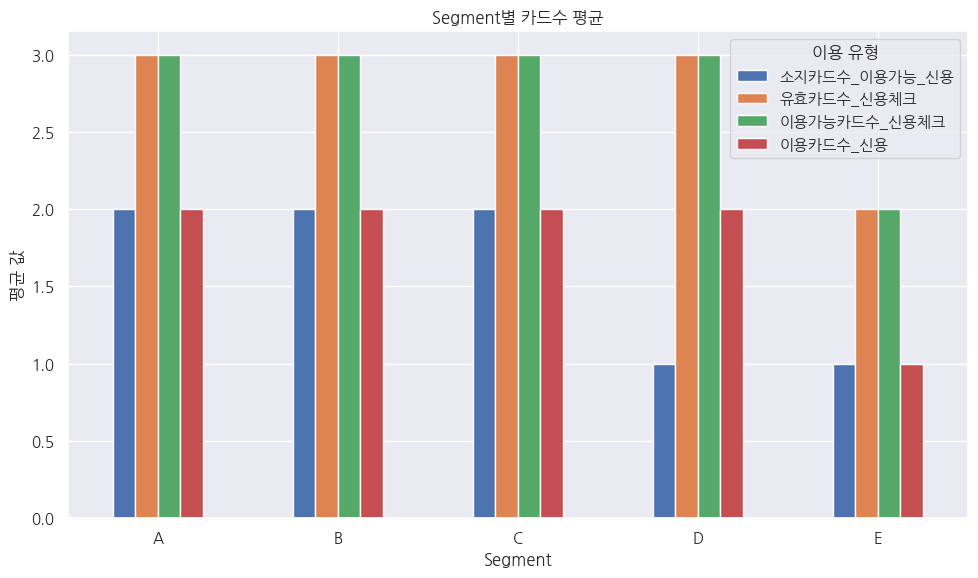

In [17]:
grouped_plot(카드수, '카드수')

In [18]:
del 카드수
gc.collect()

4679

### 이용건수
### 이용금액

In [38]:
이용건수 = [col for col in cols_list if re.search(r'(이용건수)', col)]
이용금액 = [col for col in df.columns if re.search(r'(이용금액)', col)]

#### 카드 순위별 이용 건수/금액
- 이용 건수
  - 1순위 > 2순위
  - B > A > C > D > E
  - 등급 선정시 1,2 순위 카드 이용 건수를 종합적으로 보는 것 같음
    <br>
    <br>
- 이용 금액
  - A > B > C > D > E
  - 1순위 카드 이용금액이 많은 순으로 등급을 매김

In [20]:
# def grouped_plot(col_list, plot_title):
#     tot_cols = ['Segment'] + col_list
#     grouped_df = df[tot_cols].groupby('Segment').mean().round()

#     display(grouped_df)

#     # 반드시 ax 지정해서 그리기 (레전드 누락 방지)
#     fig, ax = plt.subplots(figsize=(10, 6))
#     grouped_df.plot(kind='bar', ax=ax)

#     ax.set_title(f'Segment별 {plot_title} 평균')
#     ax.set_xlabel('Segment')
#     ax.set_ylabel('평균 값')
#     ax.set_xticks(range(len(grouped_df)))
#     ax.set_xticklabels(grouped_df.index, rotation=0)

#     ax.legend(title='이용 유형')  # 명시적으로 설정
#     plt.tight_layout()
#     plt.show()

In [23]:
순위이용건수 = [col for col in 이용건수 if re.search(r'(순위카드).+건수', col)]
순위이용건수

['1순위카드이용건수', '2순위카드이용건수']

,1순위카드이용건수,2순위카드이용건수
Segment,,
A,125.0,44.0
B,130.0,32.0
C,90.0,43.0
D,75.0,35.0
E,29.0,9.0


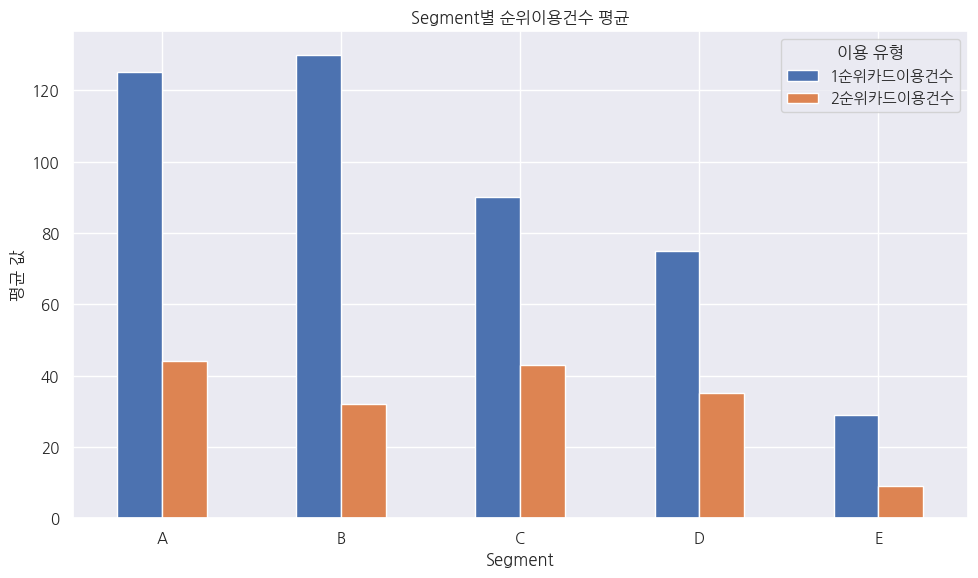

In [24]:
grouped_plot(순위이용건수, '순위이용건수')

In [40]:
일순위_이용금액 =  [col for col in 이용금액 if re.search(r'(1순위카드)', col)]
일순위_이용금액

['1순위카드이용금액']

,1순위카드이용금액
Segment,
A,72325.0
B,69699.0
C,36108.0
D,22413.0
E,7250.0


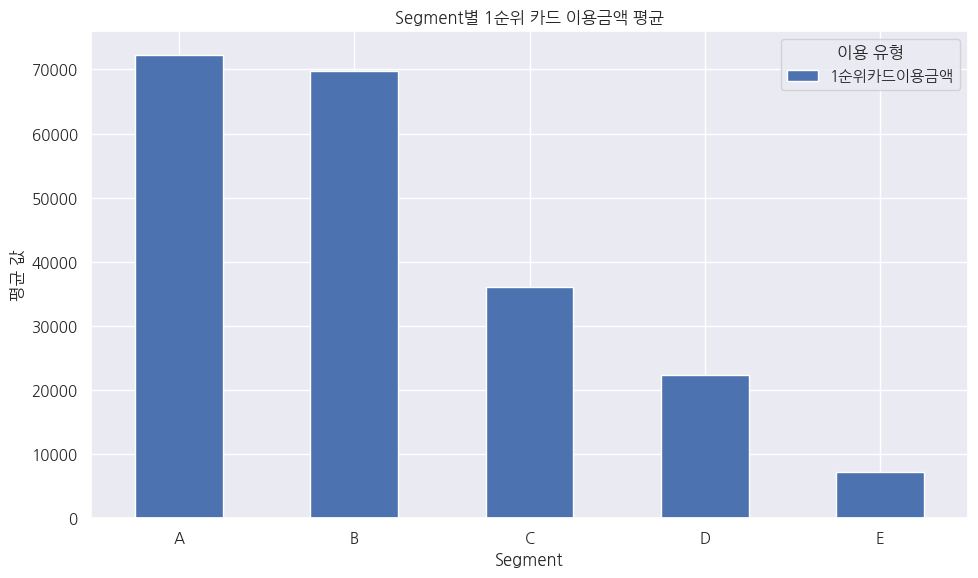

In [41]:
grouped_plot(일순위_이용금액, '1순위 카드 이용금액')

In [42]:
del 순위이용건수
del 일순위_이용금액
gc.collect()

NameError: name '순위이용건수' is not defined

#### 신용카드이용건수/이용금액
- 이용 건수
  - 누적값
  - 월별 평균 이용건수 비슷
  - B > A > C > D > E (당월 기준)
- 이용 금액
  - A > B > C > D > E

In [36]:
신용 = [col for col in 이용건수 if re.search(r'(신용)', col)]
신용 =sorted(신용, key=lambda x: int(re.search(r'(\d+)M', x).group(1)))
신용

['이용건수_신용_B0M', '이용건수_신용_R3M', '이용건수_신용_R6M', '이용건수_신용_R12M']

,이용건수_신용_B0M,이용건수_신용_R3M,이용건수_신용_R6M,이용건수_신용_R12M
Segment,,,,
A,54.0,164.0,327.0,633.0
B,55.0,170.0,342.0,661.0
C,38.0,118.0,235.0,471.0
D,30.0,90.0,183.0,369.0
E,10.0,32.0,66.0,124.0


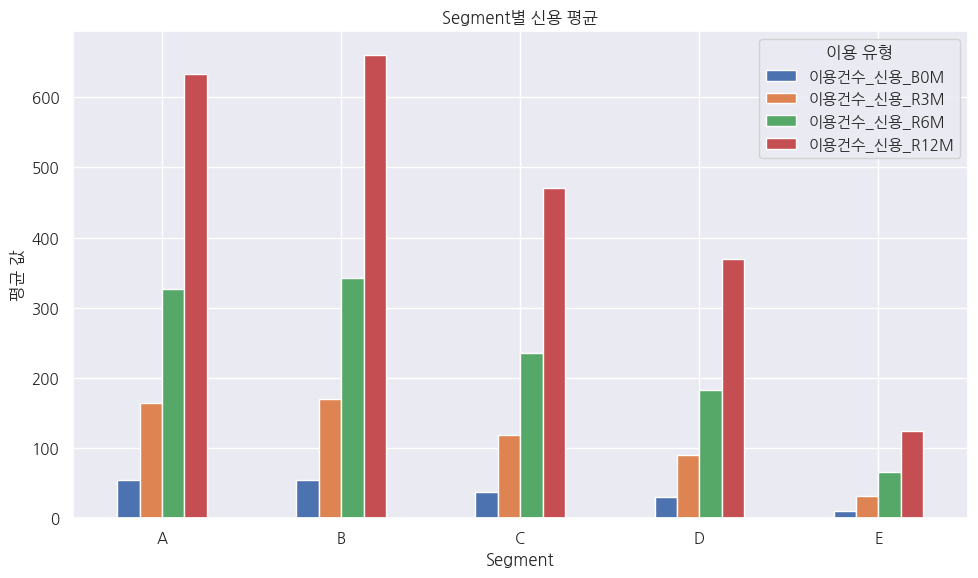

In [37]:
grouped_plot(신용, '신용')

In [43]:
신용_이용금액 = [col for col in 이용금액 if re.search(r'(신용)', col)]
신용_이용금액

['이용금액_R3M_신용']

,이용금액_R3M_신용
Segment,
A,97090.0
B,88537.0
C,54591.0
D,34187.0
E,9197.0


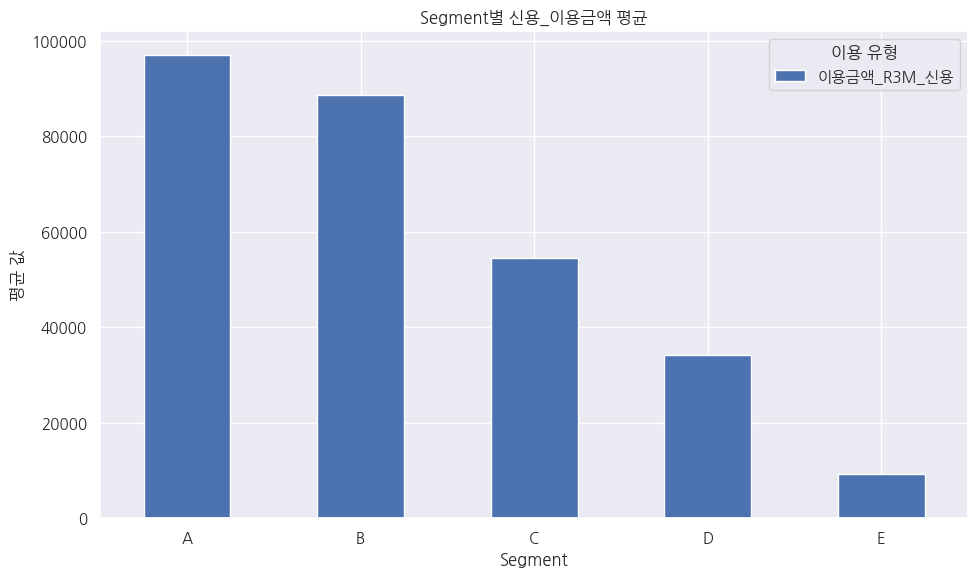

In [44]:
grouped_plot(신용_이용금액, '신용_이용금액')

In [45]:
del 신용
del 신용_이용금액
gc.collect()

13133

#### 일시불 이용 건수
- 누적값
- 하나의 컬럼만 남겨도 될 것 같음
- A/B y축 범위가 같음; E -> D -> C -> A/B
- A/B, C, D, E로 그룹핑 

In [48]:
일시불 = [col for col in 이용건수 if re.search(r'(일시불)', col)]
일시불 =sorted(일시불, key=lambda x: int(re.search(r'(\d+)M', x).group(1)))
일시불

['이용건수_일시불_B0M', '이용건수_일시불_R3M', '이용건수_일시불_R6M', '이용건수_일시불_R12M']

,이용건수_일시불_B0M,이용건수_일시불_R3M,이용건수_일시불_R6M,이용건수_일시불_R12M
Segment,,,,
A,52.0,160.0,317.0,612.0
B,53.0,163.0,326.0,626.0
C,38.0,115.0,230.0,459.0
D,29.0,89.0,179.0,360.0
E,10.0,32.0,64.0,121.0


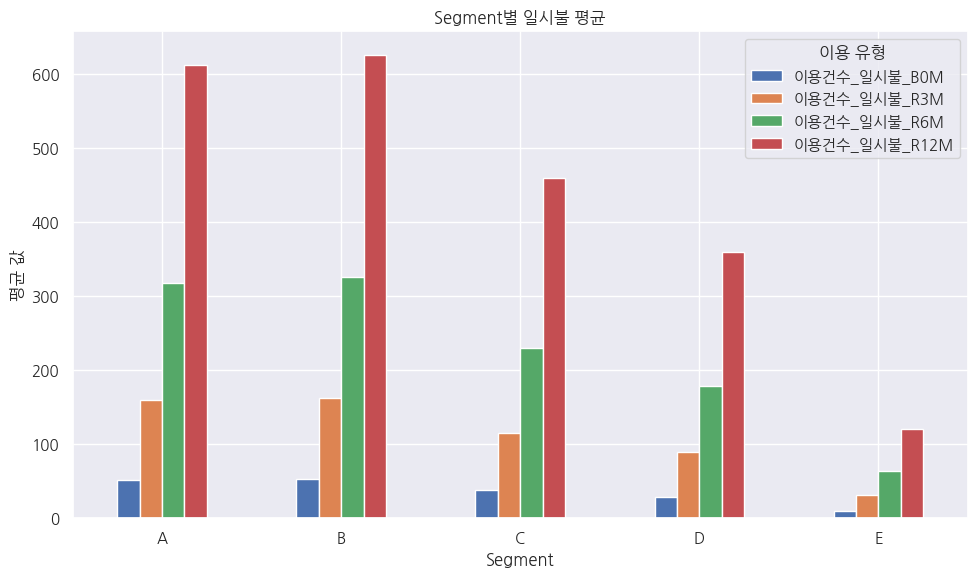

In [49]:
grouped_plot(일시불, '일시불')

In [50]:
일시불_이용금액 = [col for col in 이용금액 if re.search(r'(일시불)', col)]
일시불_이용금액 =sorted(일시불_이용금액, key=lambda x: int(re.search(r'(\d+)M', x).group(1)))
일시불_이용금액

['이용금액_일시불_B0M',
 '이용금액_일시불_R3M',
 '이용금액_일시불_R6M',
 '이용금액_일시불_R12M',
 '최대이용금액_일시불_R12M']

,이용금액_일시불_B0M,이용금액_일시불_R3M,이용금액_일시불_R6M,이용금액_일시불_R12M,최대이용금액_일시불_R12M
Segment,,,,,
A,19907.0,57948.0,114671.0,383016.0,67453.0
B,18011.0,52666.0,104607.0,323991.0,47270.0
C,11702.0,34923.0,70802.0,176200.0,31903.0
D,7407.0,22395.0,45822.0,98274.0,17729.0
E,2340.0,6962.0,14167.0,26354.0,5683.0


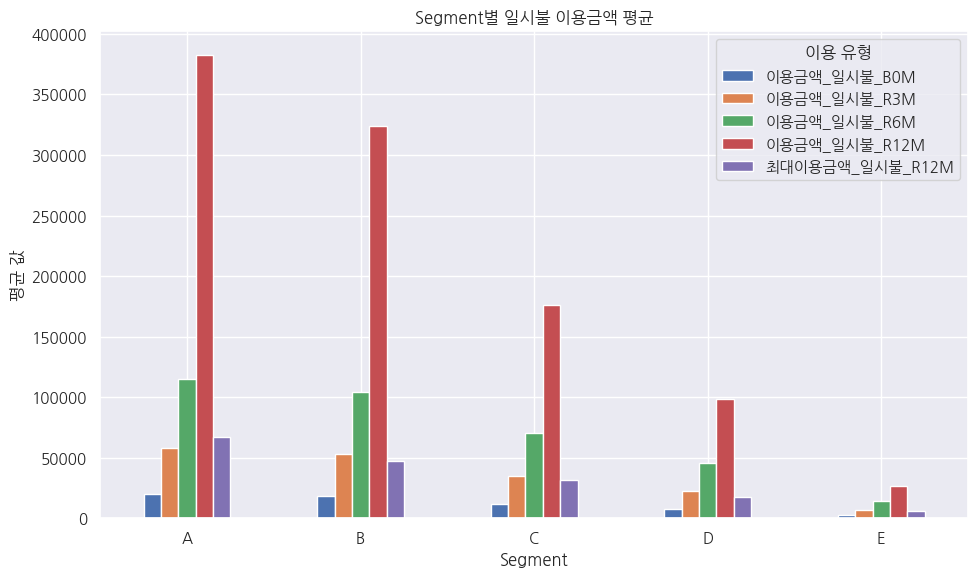

In [51]:
grouped_plot(일시불_이용금액, '일시불 이용금액')

In [ ]:
del 일시불
gc.collect()

#### 온라인/오프라인
- 온라인
  - 이용건수_페이_온라인
    - A/B/C 는 최근 3/6개월과 당월과 비슷하게 사용
  - 이용건수_온라인
    - 3/6 개월 평균값 약 두배 차이
    - 하나 없애도 될듯..?
  - 누적순
    - 이용건수페이0/3/6 -> 이용건수 온라인 3/6 순
- 오프라인
  - 누적순
    - 사용건수가 비슷 -> 컬럼 하나만 남겨도 될 듯 아님 증감율
  - (A/B) (C,D) E로 그핑


In [ ]:
온라인 = [col for col in 이용건수 if re.search(r'(온라인)', col)]
온라인

In [ ]:
grouped_plot(온라인, '온라인')

In [ ]:
del 온라인
gc.collect()

In [ ]:
오프라인 = [col for col in 이용건수 if re.search(r'(오프라인)', col)]
오프라인

In [ ]:
grouped_plot(오프라인, '오프라인')

In [ ]:
del 오프라인
gc.collect()

#### 간편결제
- 누적값
  - 개월간 평균 이용건수 비슷
  - 당월 평균 이용건수 기준 ; E -> D -> C -> A -> B

In [ ]:
간편결제 = [col for col in 이용건수 if re.search(r'(간편결제)', col)]
간편결제

In [ ]:
grouped_plot(간편결제, '간편결제')

### CA
- CA 이자율 할인전 : 현금서비스 이자율 할인전
- 최종이용일자_CA : 10101은 무엇일까?

In [ ]:
result = [x for x in result if x not in 이용건수]
len(result)

In [ ]:
CA = [col for col in result if re.search(r'(CA)', col)]
CA

In [ ]:
df['최종이용일자_CA'].value_counts()

In [ ]:
CA_drop_최종이용일자 = [col for col in result if re.search(r'^(?!최종이용일자).*(CA).*', col)]
CA_drop_최종이용일자

In [ ]:
grouped_plot(['CA한도금액'], 'CA한도금액')

### CA이자율_할인전
- 현금 서비스 이자율 할인전
- 최대 22.999954, 최소 14.21997156
  - 모든 그룹에서  1.최소 이자율 2.최대이자율 의 비중이 큼
  - 아래 등급으로 갈 수록 현금 서비스 이자율 할인전 수가 많아짐
    - 아래 등급일 수록 현금 서비스를 많이 이용한다
    <br>
    <br>
- B 등급의 이자율이 가장 높은 이유
  - 수가 가장 작기 때문
  - E > D > C > A > B 

In [ ]:
grouped_plot(['CA이자율_할인전'], 'CA이자율_할인전')

In [ ]:
print('max : ' ,df['CA이자율_할인전'].max())
print('min :' ,df['CA이자율_할인전'].min())
df['CA이자율_할인전'].value_counts()

In [ ]:
## E 그룹의 CA이자율할인전
print('A ',df.loc[df['Segment'] == 'A', 'CA이자율_할인전'].count())
print(df.loc[df['Segment'] == 'A', 'CA이자율_할인전'].value_counts().head(10))
print('B ', df.loc[df['Segment'] == 'B', 'CA이자율_할인전'].count())
print(df.loc[df['Segment'] == 'B', 'CA이자율_할인전'].value_counts().head(10))
print('C ', df.loc[df['Segment'] == 'C', 'CA이자율_할인전'].count())
print(df.loc[df['Segment'] == 'C', 'CA이자율_할인전'].value_counts().head(10))
print('D ', df.loc[df['Segment'] == 'D', 'CA이자율_할인전'].count())
print(df.loc[df['Segment'] == 'D', 'CA이자율_할인전'].value_counts().head(10))
print('E ', df.loc[df['Segment'] == 'E', 'CA이자율_할인전'].count())
print(df.loc[df['Segment'] == 'E', 'CA이자율_할인전'].value_counts().head(10))

In [ ]:
df.loc[df['Segment'] == 'B', 'CA이자율_할인전'].count()

### 이용금액

### 순위 업종 이용금액
- 0이 가장 많음
  - 총 539998개 중 511486개가 E 등급에 분포 ; 약 95%
- 1순위 업종 B > A > C > D > E
- 2/3순위 업종 A > B > C > D > E
<br>
<br>
- 등급을 나눌 때, 각 순위 업종별 종합적인 이용금액을 고려하는 것 같음

In [ ]:
순위이용금액 = [col for col in 이용금액 if re.search(r'(순위업종)', col)]
순위이용금액

In [ ]:
df['1순위업종_이용금액'].value_counts()

In [ ]:
511486/539998

In [ ]:
df.loc[df['Segment'] == 'E','1순위업종_이용금액'].value_counts()

In [ ]:
grouped_plot(순위이용금액, '순위이용금액')

In [ ]:
쇼핑이용금액 = [col for col in df.columns if re.search(r'(순위쇼핑업종)', col)]
쇼핑이용금액

In [ ]:
grouped_plot(쇼핑이용금액, '쇼핑이용금액')

In [ ]:
교통업종_이용금액 = [col for col in 이용금액 if re.search(r'.*(교통).*(업종).*',col)]
교통업종_이용금액

In [ ]:
grouped_plot(교통업종_이용금액, '교통업종_이용금액')

In [ ]:
교통이용금액 = [col for col in 이용금액 if re.search(r'.*(교통)(?!업종).*',col)]
교통이용금액

In [ ]:
grouped_plot(교통이용금액, '교통이용금액')

In [ ]:
일순위 = [col for col in 이용금액 if re.search(r'(_1순위)(?!쇼핑|교통)', col)]
일순위

In [ ]:
grouped_plot(일순위, '일순위')

In [ ]:
최대이용금액 = [col for col in 이용금액 if re.search(r'(최대)', col)]
최대이용금액

In [ ]:
grouped_plot(최대이용금액, '최대이용금액')

In [ ]:
간편결제_이용금액 = [col for col in 이용금액 if re.search(r'(간편결제)', col)]
간편결제_이용금액

In [ ]:
grouped_plot(간편결제_이용금액, '간편결제_이용금액')

In [ ]:
일시불_이용금액 = [col for col in 이용금액 if re.search(r'(일시불)', col)]
일시불_이용금액

In [ ]:
grouped_plot(일시불_이용금액, '일시불_이용금액')

In [ ]:
온라인_이용금액 = [col for col in 이용금액 if re.search(r'(온라인)', col)]
온라인_이용금액

In [ ]:
grouped_plot(온라인_이용금액, '온라인_이용금액')

In [ ]:
오프라인_이용금액 = [col for col in 이용금액 if re.search(r'(오프라인)', col)]
오프라인_이용금액

In [ ]:
grouped_plot(오프라인_이용금액, '오프라인_이용금액')

In [ ]:
이용금액

### 쇼핑 이용금액

- 쇼핑 순위 업종별 이용금액

In [ ]:
쇼핑순위 = [col for col in 이용금액 if re.search(r'^(.*순위)쇼핑(?!.*온라인).*', col)]
쇼핑순위

In [ ]:
grouped_plot(쇼핑순위, '쇼핑순위')

In [ ]:
쇼핑이용금액 =  [col for col in 이용금액 if re.search(r'^(?!업종)쇼핑(?!.*온라인).*', col)]
쇼핑이용금액

In [ ]:
grouped_plot(쇼핑이용금액, '쇼핑이용금액')

### 이용금액대
- 최근 3개월 간 월평균 이용금액 구간
- 고객이 소비한 금액 수준을 구간으로 나눈 분류 (예: 낮음, 중간, 높음 / 혹은 구간별 금액대)
  - A/B : 0 등급
  - C/D : 1 등급
  - E : 3등급
  <br>
  <br>
- 등급 순
  - 5 - 4 - 1 - 0 - 3 - 2
  - 5 등급이 가장 많음 -> E 그룹 일것 같음

In [ ]:
grouped_plot(['이용금액대'], '이용금액대')

In [ ]:
df['이용금액대'].value_counts()

In [ ]:
df['이용금액대'].head(10)

### 이용금액_R3M_신용
- 파생 컬럼인가?

In [ ]:
grouped_plot(['이용금액_R3M_신용'], '이용금액_R3M_신용')